In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import List, Dict
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne import *

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

In [3]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 51
Extracted data for [[(3.0000000817631687, 6.991934657836011e-08), 0], [(1.512344102998239, 0.013932395296170701), 1], [(0.34048750489580726, 0.035478751604426574), 2], [(-1.015718826414441, 0.0345301431008247), 3], [(-2.4914599115717384, 0.08496204398301681), 4], [(-3.295158795505818, 0.2343733313117736), 5], [(-4.062004110615584, 0.15865549389626196), 6], [(-4.710940886686118, 0.21010772943622058), 7], [(-4.848972203941356, 0.19079480233245977), 8], [(-5.124314668335285, 0.1621580343826099), 9], [(-5.36806750137307, 0.19087855942686316), 10], [(-5.530711658622038, 0.16442349747081578), 11], [(-5.68977426806609, 0.16536366548814804), 12], [(-5.724989888801153, 0.1599278825799889), 13], [(-5.797664146300366, 0.12925006513377796), 14], [(-5.8500918167345475, 0.11648195027346925), 15], [(-5.817524418404128, 0.1475214842575809), 16], [(-5.904683436616966, 0.07204586425527805), 17], [(-5.9298316312568415, 0.07567479045998024), 18], [(-5.910673807120366, 0.10301714506773366), 19], [(

In [4]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [5]:
# Extracting components
vqe_means = np.array([item[0][0] for item in EXPERIMENTAL_PROCESSED_DATA])
vqe_stds = np.array([item[0][1] for item in EXPERIMENTAL_PROCESSED_DATA])
noise_levels = np.array([item[1] for item in EXPERIMENTAL_PROCESSED_DATA])

print(f"Loaded {len(noise_levels)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 51 data points.
EXACT_SOLUTION = -6.026674183332271


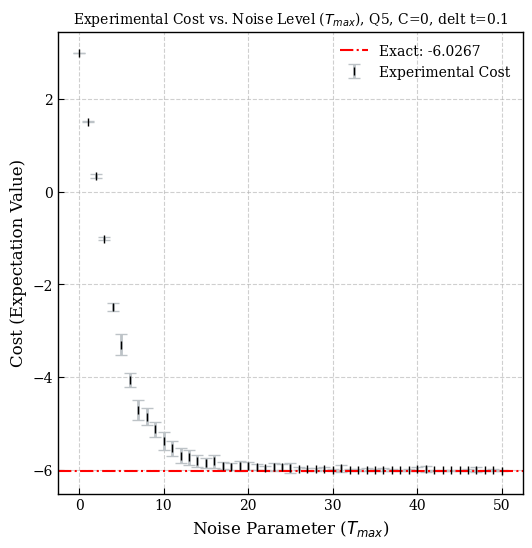

In [6]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels, vqe_means, yerr=vqe_stds, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Experimental Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

In [7]:
lsf_zne_history = {
    'logistic_decay': [],
    'logistic_shifted': [],
    'logistic_offset_shifted': []
}

In [8]:
SOLVER_KWARGS = {
    'xtol': 1e-10, 
    'ftol': 1e-10, 
    'gtol': 1e-10, 
    'maxfev': 50000, 
    'diff_step': None 
}

# 2. STEP 0: LOGISTIC DECAY APPLICATION
MODEL_0 = 'logistic_decay'

print(f"Running Step 0: {MODEL_0}")
print(f"{'WINDOW':<12} | {'ZNE VALUE':<12} | {'K':<10} | {'N':<10} | {'r':<10}")
print("-" * 65)

for t_min, t_max in LSF_WINDOWS:
    # Filter data for current window
    window_data = [d for d in EXPERIMENTAL_PROCESSED_DATA if t_min <= d[1] <= t_max]
    if not window_data:
        continue
        
    y_vals = np.array([d[0][0] for d in window_data])
    s_vals = np.array([d[0][1] for d in window_data])
    x_vals = np.array([d[1] for d in window_data])
    
    try:
        # Initialize the LSF engine
        zne_engine = LstZne(
            vqe_estimations=y_vals,
            noise_levels=x_vals,
            stds=s_vals,
            model_str=MODEL_0,
            xtol=SOLVER_KWARGS['xtol'],
            ftol=SOLVER_KWARGS['ftol'],
            gtol=SOLVER_KWARGS['gtol']
        )
        
        # Perform the fit
        zne_val = zne_engine.fit(
            maxfev=SOLVER_KWARGS['maxfev'],
            diff_step=SOLVER_KWARGS['diff_step']
        )
        
        # Get optimized coefficients
        coeffs = zne_engine.coefficients
        
        # 3. ROBUST STORAGE FOR PLOTTING
        # We store everything needed to reconstruct the fit or plot residuals later
        lsf_zne_history[MODEL_0].append({
            "window": (t_min, t_max),
            "t_max": t_max,
            "zne_value": zne_val,
            "coefficients": coeffs,
            "params_vector": zne_engine.params,
            "data": {
                "x": x_vals,
                "y": y_vals,
                "sigma": s_vals
            },
            "success": True
        })
        
        print(f"{f'[{t_min}, {t_max}]':<12} | {zne_val:<12.6f} | {coeffs['K']:<10.4f} | {coeffs['N']:<10.4f} | {coeffs['r']:<10.4f}")
            
    except Exception as e:
        # Store failure state so the index alignment with LSF_WINDOWS remains consistent
        lsf_zne_history[MODEL_0].append({
            "window": (t_min, t_max),
            "success": False,
            "error": str(e)
        })
        print(f"{f'[{t_min}, {t_max}]':<12} | FAILED: {str(e)[:20]}")

print("\nStep 0 Complete. History populated for 'logistic_decay'.")

Running Step 0: logistic_decay
WINDOW       | ZNE VALUE    | K          | N          | r         
-----------------------------------------------------------------
[0, 30]      | -2.720291    | 2.7203     | -3.0000    | 10.0000   
[0, 40]      | -3.152200    | 3.1522     | -3.0000    | 0.0686    
[0, 50]      | -4.147665    | 4.1477     | -3.0000    | 0.0755    

Step 0 Complete. History populated for 'logistic_decay'.


In [9]:
# 1. SETUP FOR STEP 1
MODEL_1 = 'logistic_shifted'
STEP_0_REF = 'logistic_decay'

print(f"Running Step 1: {MODEL_1}")
print(f"{'WINDOW':<12} | {'ZNE (SHIFTED)':<15} | {'K':<8} | {'N':<8} | {'r':<8} | {'t0':<8}")
print("-" * 85)

# 2. STEP 1 EXECUTION LOOP
for i, (t_min, t_max) in enumerate(LSF_WINDOWS):
    # Retrieve matching window data from Step 0 to ensure consistency
    try:
        step0_entry = lsf_zne_history[STEP_0_REF][i]
        
        # Check if Step 0 was successful for this window
        if not step0_entry['success']:
            raise ValueError("Step 0 failed for this window")
            
        # Extract data and coefficients
        data = step0_entry['data']
        prev_coeffs = step0_entry['coefficients']
        
        # Construct p0: [K, N, r, t0]
        # We seed K, N, r from Step 0 and start t0 at 0.0
        p0_from_step0 = [prev_coeffs['K'], prev_coeffs['N'], prev_coeffs['r'], 0.0]
        
    except (IndexError, KeyError, ValueError):
        # Fallback: Try to filter data manually if history is missing/failed
        window_data = [d for d in EXPERIMENTAL_PROCESSED_DATA if t_min <= d[1] <= t_max]
        if not window_data: continue
        data = {
            "x": np.array([d[1] for d in window_data]),
            "y": np.array([d[0][0] for d in window_data]),
            "sigma": np.array([d[0][1] for d in window_data])
        }
        p0_from_step0 = None # Let the class use its own defaults

    try:
        # Initialize LSF engine for the Shifted model
        zne_engine = LstZne(
            vqe_estimations=data['y'],
            noise_levels=data['x'],
            stds=data['sigma'],
            model_str=MODEL_1,
            xtol=SOLVER_KWARGS['xtol'],
            ftol=SOLVER_KWARGS['ftol'],
            gtol=SOLVER_KWARGS['gtol']
        )
        
        # Fit using the Step 0 seeds
        zne_val = zne_engine.fit(
            p0=p0_from_step0,
            maxfev=SOLVER_KWARGS['maxfev'],
            diff_step=SOLVER_KWARGS['diff_step']
        )
        
        coeffs = zne_engine.coefficients
        
        # 3. ROBUST STORAGE FOR PLOTTING
        lsf_zne_history[MODEL_1].append({
            "window": (t_min, t_max),
            "t_max": t_max,
            "zne_value": zne_val,
            "coefficients": coeffs,
            "params_vector": zne_engine.params,
            "data": data, # Carrying over data for plot modularity
            "seeded_from": STEP_0_REF if p0_from_step0 else "defaults",
            "success": True
        })
        
        print(f"{f'[{t_min}, {t_max}]':<12} | {zne_val:<15.6f} | {coeffs['K']:<8.3f} | {coeffs['N']:<8.3f} | {coeffs['r']:<8.3f} | {coeffs['t0']:<8.3f}")

    except Exception as e:
        lsf_zne_history[MODEL_1].append({
            "window": (t_min, t_max),
            "success": False,
            "error": str(e)
        })
        print(f"{f'[{t_min}, {t_max}]':<12} | FAILED: {str(e)[:20]}")

print("\nStep 1 Complete. History populated for 'logistic_shifted'.")

Running Step 1: logistic_shifted
WINDOW       | ZNE (SHIFTED)   | K        | N        | r        | t0      
-------------------------------------------------------------------------------------
[0, 30]      | -2.720291       | 2.720    | -3.000   | 10.000   | -0.000  
[0, 40]      | -3.136579       | 3.137    | -3.000   | 0.068    | -0.000  
[0, 50]      | -4.147353       | 4.147    | -3.000   | 0.076    | -0.000  

Step 1 Complete. History populated for 'logistic_shifted'.


In [10]:
# 1. SETUP FOR STEP 3
MODEL_2 = 'logistic_offset_shifted'
STEP_1_REF = 'logistic_shifted'

print(f"Running Step 3: {MODEL_2}")
print(f"{'WINDOW':<12} | {'ZNE (OFFSET)':<15} | {'K':<7} | {'N':<7} | {'r':<7} | {'t0':<7} | {'C':<7}")
print("-" * 105)

# 2. STEP 3 EXECUTION LOOP
for i, (t_min, t_max) in enumerate(LSF_WINDOWS):
    try:
        # Retrieve the specific solution from Step 1 (Logistic Shifted)
        step1_entry = lsf_zne_history[STEP_1_REF][i]
        
        if not step1_entry['success']:
            raise ValueError("Step 1 failed for this window")
            
        data = step1_entry['data']
        p1_coeffs = step1_entry['coefficients']
        
        # Construct p0: [K, N, r, t0, C]
        # We seed K, N, r, t0 from Step 1.
        # For C (offset), we initialize at 0.0 or the last Y value for stability.
        p0_from_step1 = [
            p1_coeffs['K'], 
            p1_coeffs['N'], 
            p1_coeffs['r'], 
            p1_coeffs['t0'], 
            0.0 # Initial guess for C
        ]
        
    except (IndexError, KeyError, ValueError):
        # Fallback if Step 1 is missing
        window_data = [d for d in EXPERIMENTAL_PROCESSED_DATA if t_min <= d[1] <= t_max]
        if not window_data: continue
        data = {
            "x": np.array([d[1] for d in window_data]),
            "y": np.array([d[0][0] for d in window_data]),
            "sigma": np.array([d[0][1] for d in window_data])
        }
        p0_from_step1 = None

    try:
        # Initialize engine for logistic_offset_shifted
        zne_engine = LstZne(
            vqe_estimations=data['y'],
            noise_levels=data['x'],
            stds=data['sigma'],
            model_str=MODEL_2,
            xtol=SOLVER_KWARGS['xtol'],
            ftol=SOLVER_KWARGS['ftol'],
            gtol=SOLVER_KWARGS['gtol']
        )
        
        # Fit using the Step 1 seeds
        zne_val = zne_engine.fit(
            p0=p0_from_step1,
            maxfev=SOLVER_KWARGS['maxfev'],
            diff_step=SOLVER_KWARGS['diff_step']
        )
        
        coeffs = zne_engine.coefficients
        
        # 3. ROBUST STORAGE FOR PLOTTING
        lsf_zne_history[MODEL_2].append({
            "window": (t_min, t_max),
            "t_max": t_max,
            "zne_value": zne_val,
            "coefficients": coeffs,
            "params_vector": zne_engine.params,
            "data": data,
            "seeded_from": STEP_1_REF if p0_from_step1 else "defaults",
            "success": True
        })
        
        print(f"{f'[{t_min}, {t_max}]':<12} | {zne_val:<15.6f} | "
              f"{coeffs['K']:<7.2f} | {coeffs['N']:<7.2f} | {coeffs['r']:<7.2f} | "
              f"{coeffs['t0']:<7.2f} | {coeffs['C']:<7.2f}")

    except Exception as e:
        lsf_zne_history[MODEL_2].append({
            "window": (t_min, t_max),
            "success": False,
            "error": str(e)
        })
        print(f"{f'[{t_min}, {t_max}]':<12} | FAILED: {str(e)[:20]}")

print("\nStep 3 Complete. History populated for 'logistic_offset_shifted'.")

Running Step 3: logistic_offset_shifted
WINDOW       | ZNE (OFFSET)    | K       | N       | r       | t0      | C      
---------------------------------------------------------------------------------------------------------
[0, 30]      | -2.720403       | 2.72    | -3.00   | 10.00   | -0.00   | -0.00  
[0, 40]      | FAILED: Optimal parameters n
[0, 50]      | FAILED: Optimal parameters n

Step 3 Complete. History populated for 'logistic_offset_shifted'.


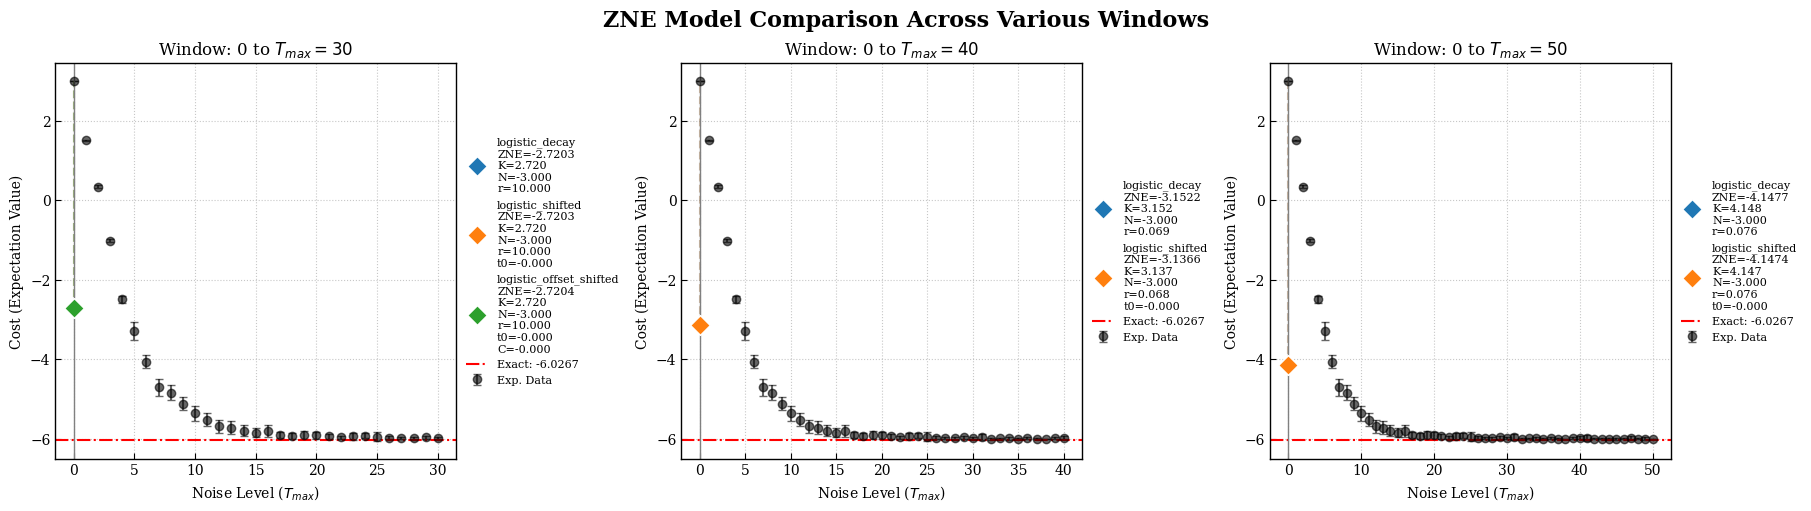

In [13]:
# 1. SETUP PLOT GEOMETRY
n_windows = len(LSF_WINDOWS)
cols = 3
rows = (n_windows + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), constrained_layout=True)
axes = axes.flatten()

# Colors for model differentiation
model_colors = {
    'logistic_decay': '#1f77b4',
    'logistic_shifted': '#ff7f0e',
    'logistic_offset_shifted': '#2ca02c'
}

# 2. PLOTTING LOOP
for i, (t_min, t_max) in enumerate(LSF_WINDOWS):
    ax = axes[i]
    
    # --- Plot Experimental Data ---
    # We pull the data from the first successful model entry for this window
    window_data = None
    for model_key in lsf_zne_history:
        if i < len(lsf_zne_history[model_key]) and lsf_zne_history[model_key][i]['success']:
            window_data = lsf_zne_history[model_key][i]['data']
            break
            
    if window_data:
        ax.errorbar(
            window_data['x'], window_data['y'], yerr=window_data['sigma'],
            fmt='o', color='black', label='Exp. Data', capsize=3, alpha=0.6
        )

    # --- Plot ZNE Values from History ---
    for model_name in lsf_zne_history:
        try:
            res = lsf_zne_history[model_name][i]
            if not res['success']: continue
            
            zne_val = res['zne_value']
            coeffs = res['coefficients']
            
            # Create a label string containing the model name and its optimized parameters
            param_str = "\n".join([f"{k}={v:.3f}" for k, v in coeffs.items()])
            label = f"{model_name}\nZNE={zne_val:.4f}\n{param_str}"
            
            # Plot the ZNE value at T=0
            ax.scatter(0, zne_val, color=model_colors[model_name], s=100, 
                       marker='D', label=label, edgecolor='white', zorder=5)
            
            # Optional: Draw a dashed line from ZNE point to first data point to guide the eye
            ax.plot([0, window_data['x'][0]], [zne_val, window_data['y'][0]], 
                    '--', color=model_colors[model_name], alpha=0.3)
            
        except (IndexError, KeyError):
            continue

    # Formatting
    ax.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
    ax.set_title(f"Window: 0 to $T_{{max}} = {t_max}$")
    ax.set_xlabel("Noise Level ($T_{max}$)")
    ax.set_ylabel("Cost (Expectation Value)")
    ax.axvline(0, color='gray', lw=1, ls='-') # Zero noise line
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("ZNE Model Comparison Across Various Windows", fontsize=16, fontweight='bold')
plt.show()